In [1]:
files <- list.files(path = "../RNA_seq_unstim", pattern = "*.tab", full.names = TRUE)

In [2]:
IRdisplay::display_html(
  paste0(
    "<h3>RNA-seq files</h3><ul>",
    paste0("<li>", files, "</li>", collapse = ""),
    "</ul>"
  )
)

RNA-seq files ../RNA_seq_unstim/20181128_qKO_unstim_1_ReadsPerGene.tab ../RNA_seq_unstim/20181128_qKO_unstim_2_ReadsPerGene.tab ../RNA_seq_unstim/20181128_qKO_unstim_3_ReadsPerGene.tab ../RNA_seq_unstim/20181128_WT_unstim_1_ReadsPerGene.tab ../RNA_seq_unstim/20181128_WT_unstim_2_ReadsPerGene.tab ../RNA_seq_unstim/20181128_WT_unstim_3_ReadsPerGene.tab

In [3]:
# Sample names (custom, consistent)
sample_names <- c("qKO_rep1", "qKO_rep2", "qKO_rep3",
                  "WT_rep1", "WT_rep2", "WT_rep3")

# Read function
read_counts <- function(file, sample_name) {
  df <- read.table(file, header = FALSE, sep = "\t", stringsAsFactors = FALSE)
  df <- df[, c(1, (ncol(df) - 2):ncol(df))]  # Geneid and last 3 columns
  df$Sum <- rowSums(df[, 2:4])  # Calculate the sum of the last 3 columns
  # df$Max <- apply(df[, 2:4], 1, max)  # Calculate the max of the last 3 columns
  df <- df[, c(1, ncol(df))]  # Keep only Geneid and the Average column
  colnames(df) <- c("Geneid", sample_name)
  return(df)
}

# Loop through all files and sample names
count_list <- mapply(read_counts, files, sample_names, SIMPLIFY = FALSE)

# Merge them all by Geneid
merged_counts <- Reduce(function(x, y) merge(x, y, by = "Geneid", sort = FALSE), count_list)

# Set Geneid as rownames
rownames(merged_counts) <- merged_counts$Geneid
merged_counts <- merged_counts[, -1]  # drop Geneid column

head(merged_counts, 20)

,qKO_rep1,qKO_rep2,qKO_rep3,WT_rep1,WT_rep2,WT_rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
N_unmapped,1449960,1666941,1536252,1852578,2113014,1495806
N_multimapping,7499187,8829579,6984096,8135238,9043485,8580954
N_noFeature,24018662,26555385,23169930,24804611,28468343,21886175
N_ambiguous,1430737,1392902,1262707,1430591,1774363,1421267
ENSMUSG00000102693.1,0,0,0,0,0,0
ENSMUSG00000064842.1,0,0,0,0,0,0
ENSMUSG00000051951.5,0,2,8,2,0,4
ENSMUSG00000102851.1,0,0,0,0,0,0
ENSMUSG00000103377.1,0,0,0,0,0,0


In [4]:
counts <- merged_counts[-c(1:4),]

write.csv(counts, file = "../processed/RNA_seq_unstim_counts.csv", row.names = TRUE)

In [5]:
# Delete the first 4 rows
cl_counts <- merged_counts[-c(1:4), ]

# Delete columns 3 and 6
cl_counts <- cl_counts[, -c(3, 6)]

head(cl_counts)

,qKO_rep1,qKO_rep2,WT_rep1,WT_rep2
,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000102693.1,0,0,0,0
ENSMUSG00000064842.1,0,0,0,0
ENSMUSG00000051951.5,0,2,2,0
ENSMUSG00000102851.1,0,0,0,0
ENSMUSG00000103377.1,0,0,0,0
ENSMUSG00000104017.1,0,0,0,0


In [6]:
# Calculate max value for each column
max_values <- apply(merged_counts, 2, max)

# Calculate average value for each column
average_values <- apply(merged_counts, 2, mean)

# Create an HTML table
html_table <- paste0(
    "<table border='1' style='border-collapse: collapse; width: 50%; text-align: center;'>",
    "<tr><th>Sample</th><th>Max Value</th><th>Average Value</th></tr>",
    paste0(
        "<tr><td>", names(max_values), "</td><td>", max_values, "</td><td>", round(average_values, 2), "</td></tr>",
        collapse = ""
    ),
    "</table>"
)

# Display the HTML table
IRdisplay::display_html(html_table)

Sample,Max Value,Average Value
qKO_rep1,19714214,757.88
qKO_rep2,21452803,822.44
qKO_rep3,19671494,758.01
WT_rep1,20584462,796.94
WT_rep2,24230469,943.15
WT_rep3,18841781,745.4


In [7]:
# save.image(file = "../processed/RNA_seq_PCA_env.RData")

In [6]:
write.csv(cl_counts, file = "../processed/cl_counts.csv", row.names = TRUE)

In [9]:
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The following objects are masked from 'package:base':

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: 'IRanges'


The following object is masked from 'package:grDe

In [10]:
#1 Create DESeqDataSet object
coldata <- data.frame(
  row.names = colnames(merged_counts),
  condition = factor(c("qKO1", "qKO2", "qKO3", "WT1", "WT2", "WT3"))
)
head(coldata)

# 2. Create DESeqDataSet
dds <- DESeqDataSetFromMatrix(countData = merged_counts,
                              colData = coldata,
                              design = ~ condition)
# 3. Filter out low-count genes (optional but common)
dds <- dds[ rowSums(counts(dds)) > 10, ]

# 4. Apply VST
vsd <- vst(dds, blind = TRUE)

,condition
,<fct>
qKO_rep1,qKO1
qKO_rep2,qKO2
qKO_rep3,qKO3
WT_rep1,WT1
WT_rep2,WT2
WT_rep3,WT3


using ntop=500 top features by variance



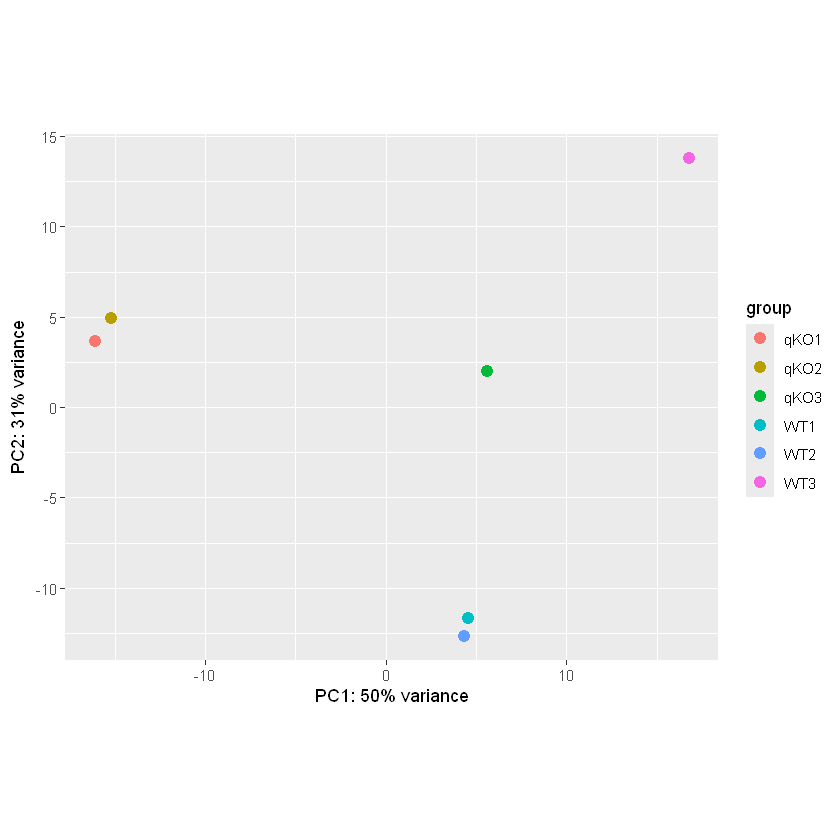

In [11]:
plotPCA(vsd, intgroup = "condition")

In [12]:
conditions <- c("qKO1", "qKO2",  "WT1", "WT2")
coldata <- data.frame(
  row.names = colnames(cl_counts),
  condition = factor(conditions)
)

In [13]:
library(edgeR)

# Ensure data is a matrix of integers
merged_counts <- as.matrix(cl_counts)

# Create DGEList object
dge <- DGEList(counts = cl_counts, group = coldata$condition)

# Normalize
dge <- calcNormFactors(dge)

# Log2 CPM transformation
logCPM <- cpm(dge, log = TRUE, prior.count = 1)

Loading required package: limma


Attaching package: 'limma'


The following object is masked from 'package:DESeq2':

    plotMA


The following object is masked from 'package:BiocGenerics':

    plotMA




In [14]:
pca <- prcomp(t(logCPM))

# Make a dataframe for ggplot
pca_df <- as.data.frame(pca$x)
pca_df$condition <- coldata$condition

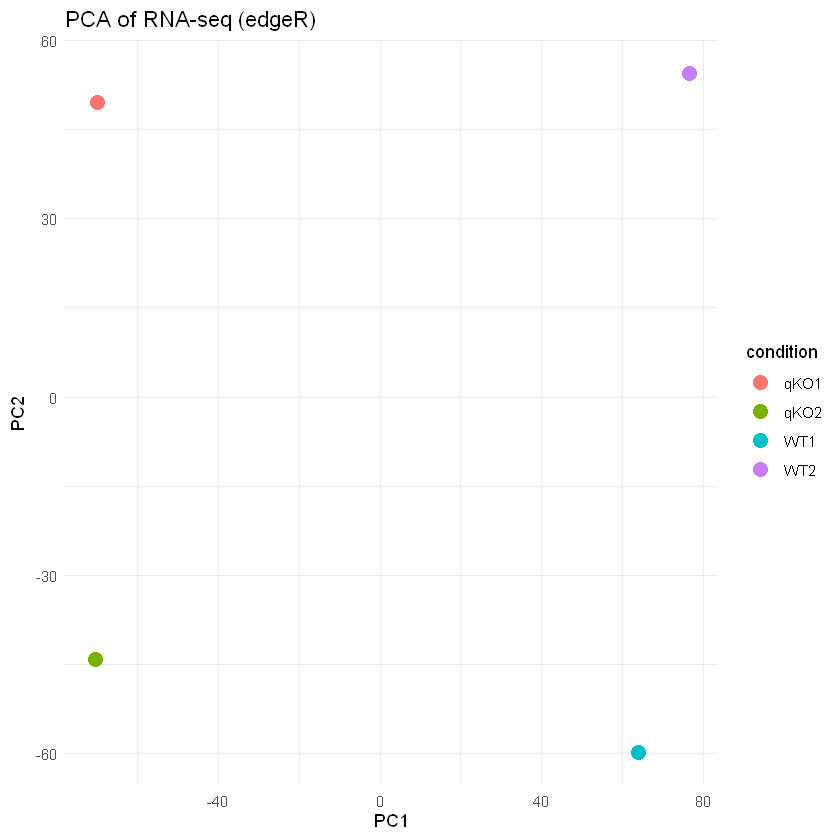

In [15]:
library(ggplot2)

ggplot(pca_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  labs(title = "PCA of RNA-seq (edgeR)", x = "PC1", y = "PC2") +
  theme_minimal()